In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
# Standard and ML Libraries
import os
import cv2
import numpy as np
import pandas as pd
import random
import shutil
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from collections import defaultdict
from PIL import Image

# PyTorch Libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
import timm

# Scikit-learn Libraries
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Reproducibility
SEED = 42
def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

seed_everything(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print("All libraries installed and imported successfully.")

Using device: cuda
All libraries installed and imported successfully.


Found 7909 images belonging to 8 classes.
Class Mapping: {0: 'adenosis', 1: 'ductal_carcinoma', 2: 'fibroadenoma', 3: 'lobular_carcinoma', 4: 'mucinous_carcinoma', 5: 'papillary_carcinoma', 6: 'phyllodes_tumor', 7: 'tubular_adenoma'}

Original Class Distribution:


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


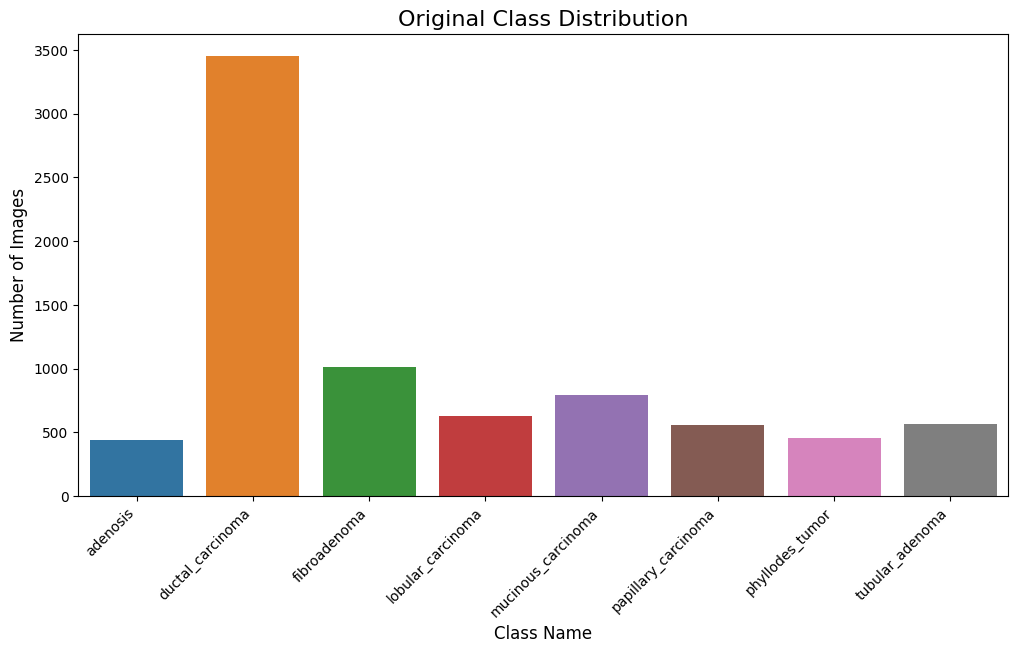

In [2]:
# Cell 2: Data Loading and Distribution Plotting
def plot_class_distributions(labels, class_names, title):
    """Plots the distribution of classes."""
    class_counts = defaultdict(int)
    for label in labels:
        class_counts[label] += 1
    
    sorted_counts = [class_counts[i] for i in range(len(class_names))]
    
    plt.figure(figsize=(12, 6))
    sns.barplot(x=class_names, y=sorted_counts)
    plt.title(title, fontsize=16)
    plt.xlabel("Class Name", fontsize=12)
    plt.ylabel("Number of Images", fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.show()

def read_multiclass_data(base_path):
    """
    Reads the BreakHis dataset and organizes it by zoom level and class.
    """
    all_images, all_labels = [], []
    label_map_inv = {}
    class_index = 0

    # First go into 'classificacao_multiclasse' folder (ignore binary for now)
    multi_path = os.path.join(base_path, "classificacao_multiclasse")

    # Loop over zoom levels
    for zoom_level in sorted(os.listdir(multi_path)):
        zoom_path = os.path.join(multi_path, zoom_level)
        if os.path.isdir(zoom_path):
            # Loop over class names
            for class_name in sorted(os.listdir(zoom_path)):
                class_path = os.path.join(zoom_path, class_name)
                if os.path.isdir(class_path):
                    if class_name not in label_map_inv.values():
                        label_map_inv[class_index] = class_name
                        current_class = class_index
                        class_index += 1
                    else:
                        current_class = list(label_map_inv.values()).index(class_name)

                    # Get all image files
                    image_files = [f for f in os.listdir(class_path) if f.endswith(('.png', '.jpg', '.jpeg'))]
                    for img_file in image_files:
                        full_path = os.path.join(class_path, img_file)
                        all_images.append(full_path)
                        all_labels.append(current_class)

    return all_images, all_labels, label_map_inv


# Use multiclass path
base_path = "/kaggle/input/breakhis-breast-cancer-histopathological-dataset/BreakHis - Breast Cancer Histopathological Database/dataset_cancer_v1/dataset_cancer_v1"
all_images, all_labels, label_map = read_multiclass_data(base_path)

NUM_CLASSES = len(label_map)
CLASS_NAMES = [label_map[i] for i in range(NUM_CLASSES)]

print(f"Found {len(all_images)} images belonging to {NUM_CLASSES} classes.")
print("Class Mapping:", label_map)

print("\nOriginal Class Distribution:")
plot_class_distributions(all_labels, CLASS_NAMES, "Original Class Distribution")

Targeting approximately 988 samples per class.

Total images after balancing: 7904
Balanced Class Distribution:


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


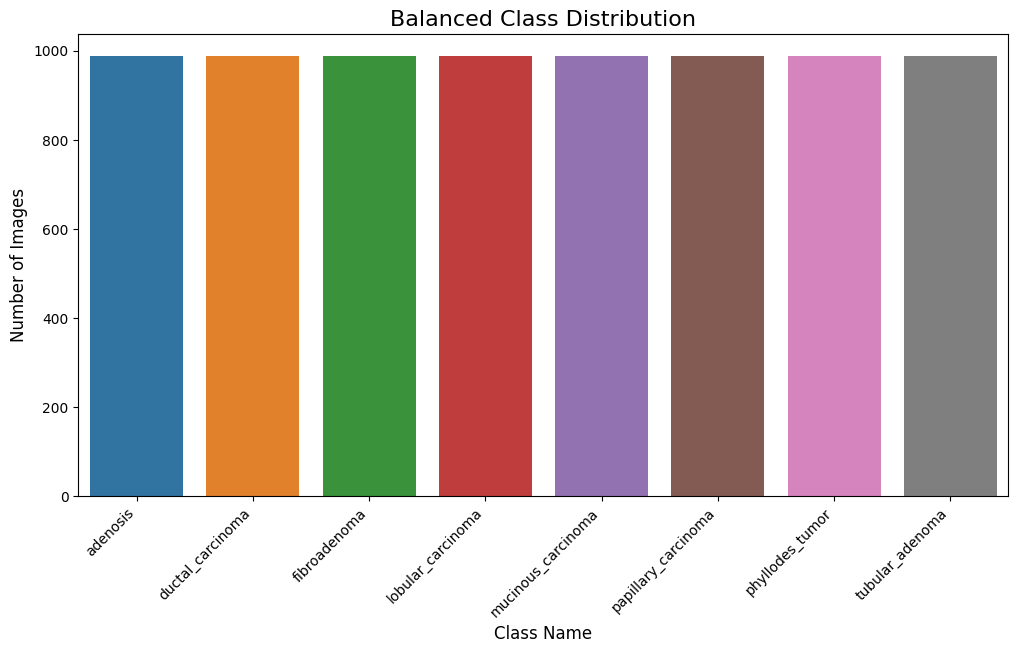

In [3]:
# Cell 3: Data Balancing by Oversampling/Undersampling

def balance_dataset(image_paths, labels):
    """Balances the dataset so each class has the mean number of samples."""
    class_distribution = {k: v for k, v in zip(*np.unique(labels, return_counts=True))}
    mean_count = int(np.mean(list(class_distribution.values())))
    
    print(f"Targeting approximately {mean_count} samples per class.")

    balanced_image_paths, balanced_labels = [], []

    for class_id, count in class_distribution.items():
        class_indices = [i for i, label in enumerate(labels) if label == class_id]
        class_images = [image_paths[i] for i in class_indices]

        if count < mean_count: # Oversample
            chosen_images = random.choices(class_images, k=mean_count)
        else: # Undersample
            chosen_images = random.sample(class_images, k=mean_count)
            
        balanced_image_paths.extend(chosen_images)
        balanced_labels.extend([class_id] * mean_count)

    return balanced_image_paths, balanced_labels

balanced_image_paths, balanced_labels = balance_dataset(all_images, all_labels)

print(f"\nTotal images after balancing: {len(balanced_image_paths)}")
print("Balanced Class Distribution:")
plot_class_distributions(balanced_labels, CLASS_NAMES, "Balanced Class Distribution")

Visualizing the effect of CLAHE preprocessing:


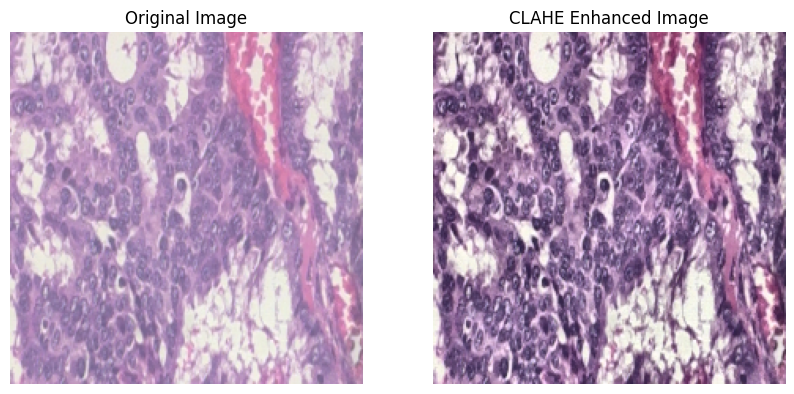

In [4]:
# Cell 4: Custom PyTorch Dataset with Preprocessing (CLAHE)

def apply_clahe_to_color_image(image):
    """Applies CLAHE contrast enhancement to a color image."""
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)
    lab = cv2.merge((cl, a, b))
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB) # Return RGB for PIL

class BreastCancerDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None, apply_clahe=False):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        self.apply_clahe = apply_clahe

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        label = self.labels[idx]
        
        # Load image with OpenCV
        image = cv2.imread(image_path)
        
        # Apply CLAHE if specified
        if self.apply_clahe:
            image = apply_clahe_to_color_image(image)
        else:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # Convert to RGB
            
        # Convert to PIL Image to apply torchvision transforms
        image = Image.fromarray(image)
        
        if self.transform:
            image = self.transform(image)
            
        return image, torch.tensor(label, dtype=torch.long)

# Visualize an original vs. CLAHE-enhanced image
def visualize_clahe(image_path):
    original_img = cv2.imread(image_path)
    clahe_img = apply_clahe_to_color_image(original_img)
    
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(clahe_img)
    plt.title("CLAHE Enhanced Image")
    plt.axis('off')
    plt.show()

print("Visualizing the effect of CLAHE preprocessing:")
visualize_clahe(random.choice(balanced_image_paths))

In [30]:
# Cell 5: Data Splitting and DataLoader Creation

# Split data into training (70%), validation (15%), and test (15%)
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    balanced_image_paths, balanced_labels, test_size=0.3, random_state=SEED, stratify=balanced_labels
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.5, random_state=SEED, stratify=temp_labels
)

print(f"Training samples: {len(train_paths)}")
print(f"Validation samples: {len(val_paths)}")
print(f"Test samples: {len(test_paths)}")

# Define transforms
IMG_SIZE = 224
BATCH_SIZE = 32

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_test_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Create Dataset instances
# We apply CLAHE to all splits as it's a preprocessing step, not augmentation
train_ds = BreastCancerDataset(train_paths, train_labels, transform=train_tfms, apply_clahe=True)
val_ds = BreastCancerDataset(val_paths, val_labels, transform=val_test_tfms, apply_clahe=True)
test_ds = BreastCancerDataset(test_paths, test_labels, transform=val_test_tfms, apply_clahe=True)

# Create DataLoader instances
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"\nDataLoaders created successfully.")

Training samples: 5532
Validation samples: 1186
Test samples: 1186

DataLoaders created successfully.


In [31]:
def create_squeezenet_model(num_classes=8, pretrained=True):
    """
    Creates a SqueezeNet 1.1 model with a modified classifier.
    The attention blocks have been removed.
    """
    model = models.squeezenet1_1(pretrained=pretrained)
    
    # Replace the final convolutional layer in the classifier
    model.classifier[1] = nn.Conv2d(512, num_classes, kernel_size=1)
    
    # Reset the number of classes attribute
    model.num_classes = num_classes
    
    return model

print("Standard SqueezeNet model architecture is defined.")

Standard SqueezeNet model architecture is defined.


In [32]:
def train_model(model, train_loader, val_loader, model_name="model", epochs=25, lr=1e-4, patience=5):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    
    scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

    best_acc = 0.0
    best_ckpt_path = f"/kaggle/working/{model_name}_best.pth"
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    no_improve_epochs = 0

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss, running_corrects, total = 0.0, 0, 0
        pbar_train = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs} [T]", leave=False)
        
        for inputs, labels in pbar_train:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            
            with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            total += labels.size(0)
            pbar_train.set_postfix(loss=f"{running_loss/total:.4f}", acc=f"{running_corrects.double()/total:.4f}")

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = running_corrects.double() / len(train_loader.dataset)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc.item())

        model.eval()
        val_loss, val_corrects, val_total = 0.0, 0, 0
        pbar_val = tqdm(val_loader, desc=f"Epoch {epoch}/{epochs} [V]", leave=False)
        
        with torch.no_grad():
            for inputs, labels in pbar_val:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)
                val_loss += loss.item() * inputs.size(0)
                val_corrects += torch.sum(preds == labels.data)
        
        val_loss /= len(val_loader.dataset)
        val_acc = val_corrects.double() / len(val_loader.dataset)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc.item())

        scheduler.step()
        
        print(f"Epoch {epoch:02d}: Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        if val_acc > best_acc:
            best_acc = val_acc
            no_improve_epochs = 0
            torch.save(model.state_dict(), best_ckpt_path)
            print(f"  -> New best model saved with accuracy: {best_acc:.4f}")
        else:
            no_improve_epochs += 1

        if no_improve_epochs >= patience:
            print(f"Early stopping triggered after {patience} epochs with no improvement.")
            break

    print(f"\nTraining finished. Best val Acc: {best_acc:.4f}")
    model.load_state_dict(torch.load(best_ckpt_path))
    return model, history, best_ckpt_path


In [33]:
squeezenet_model = create_squeezenet_model(num_classes=NUM_CLASSES, pretrained=True)

# Train the model
squeezenet_model, history, ckpt_path = train_model(
    squeezenet_model, train_loader, val_loader,
    model_name="SqueezeNet_BreakHis", epochs=30, lr=5e-5, patience=7
)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=SqueezeNet1_1_Weights.IMAGENET1K_V1`. You can also use `weights=SqueezeNet1_1_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/tmp/ipykernel_36/2337374906.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))


Epoch 1/30 [T]:   0%|          | 0/173 [00:00<?, ?it/s]

/tmp/ipykernel_36/2337374906.py:23: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


Epoch 1/30 [V]:   0%|          | 0/38 [00:00<?, ?it/s]

Epoch 01: Train Loss: 1.7858 Acc: 0.3281 | Val Loss: 1.4780 Acc: 0.4519
  -> New best model saved with accuracy: 0.4519


...

Epoch 28/30 [V]:   0%|          | 0/38 [00:00<?, ?it/s]

Epoch 28: Train Loss: 0.4197 Acc: 0.8407 | Val Loss: 0.4528 Acc: 0.8373


Epoch 29/30 [T]:   0%|          | 0/173 [00:00<?, ?it/s]

Epoch 29/30 [V]:   0%|          | 0/38 [00:00<?, ?it/s]

Epoch 29: Train Loss: 0.4338 Acc: 0.8398 | Val Loss: 0.4538 Acc: 0.8432
Early stopping triggered after 7 epochs with no improvement.

Training finished. Best val Acc: 0.8550


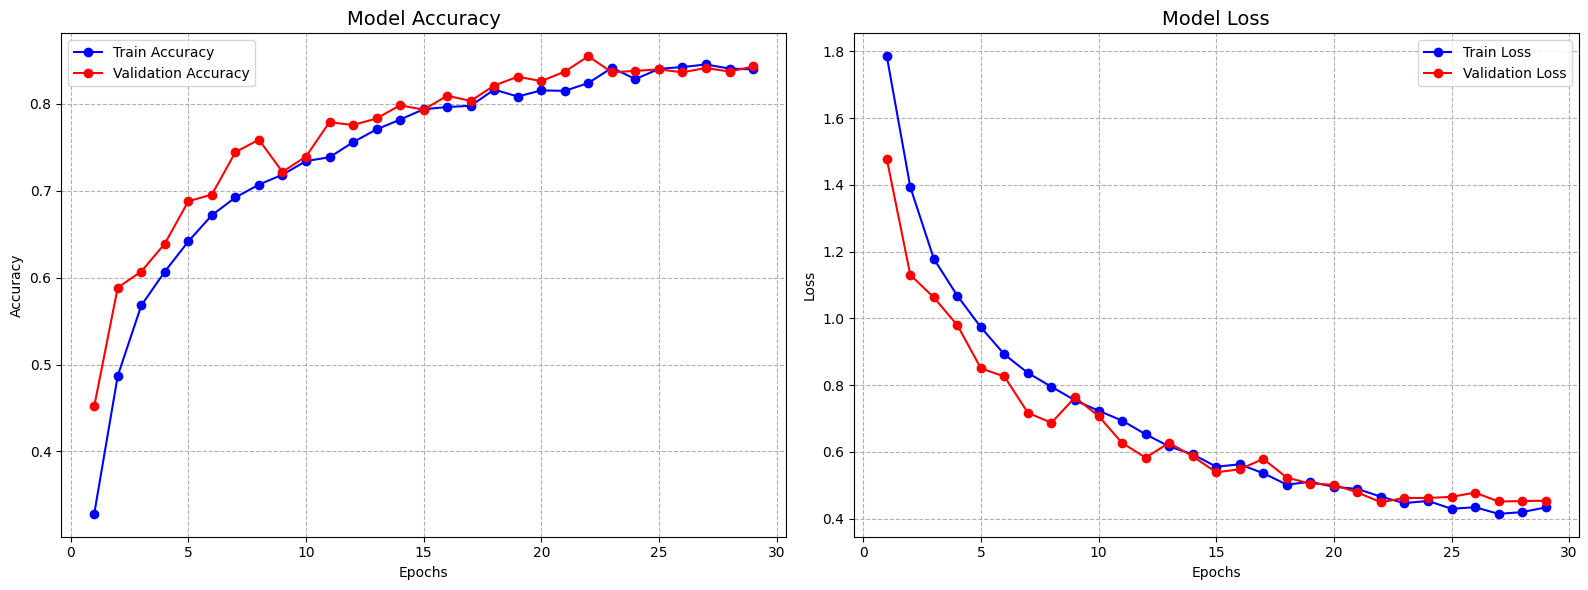

In [36]:
def plot_training_history(history):
    """Plots training and validation accuracy and loss."""
    train_acc = history['train_acc']
    val_acc = history['val_acc']
    train_loss = history['train_loss']
    val_loss = history['val_loss']
    epochs = range(1, len(train_acc) + 1)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    ax1.plot(epochs, train_acc, 'b-o', label='Train Accuracy')
    ax1.plot(epochs, val_acc, 'r-o', label='Validation Accuracy')
    ax1.set_title('Model Accuracy', fontsize=14)
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, linestyle='--')
    
    ax2.plot(epochs, train_loss, 'b-o', label='Train Loss')
    ax2.plot(epochs, val_loss, 'r-o', label='Validation Loss')
    ax2.set_title('Model Loss', fontsize=14)
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, linestyle='--')
    
    plt.tight_layout()
    plt.show()

plot_training_history(history)

In [37]:
def create_shufflenet_model(num_classes=8, pretrained=True):
    """
    Creates a ShuffleNetV2 model with a modified classifier.
    """
    model = models.shufflenet_v2_x1_0(pretrained=pretrained)
    
    # Replace the final fully connected layer in the classifier
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    
    # Reset the number of classes attribute
    model.num_classes = num_classes
    
    return model

print("ShuffleNetV2 model architecture is defined.")


ShuffleNetV2 model architecture is defined.


In [38]:
shufflenet_model = create_shufflenet_model(num_classes=NUM_CLASSES, pretrained=True)

shufflenet_model, history, ckpt_path = train_model(
    shufflenet_model, train_loader, val_loader,
    model_name="ShuffleNet_BreakHis", epochs=30, lr=5e-5, patience=7
)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ShuffleNet_V2_X1_0_Weights.IMAGENET1K_V1`. You can also use `weights=ShuffleNet_V2_X1_0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/shufflenetv2_x1-5666bf0f80.pth" to /root/.cache/torch/hub/checkpoints/shufflenetv2_x1-5666bf0f80.pth
100%|██████████| 8.79M/8.79M [00:00<00:00, 92.2MB/s]
/tmp/ipykernel_36/2337374906.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))


Epoch 1/30 [T]:   0%|          | 0/173 [00:00<?, ?it/s]

/tmp/ipykernel_36/2337374906.py:23: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


Epoch 1/30 [V]:   0%|          | 0/38 [00:00<?, ?it/s]

Epoch 01: Train Loss: 2.0636 Acc: 0.2565 | Val Loss: 2.0209 Acc: 0.3710
  -> New best model saved with accuracy: 0.3710


...

Epoch 29/30 [V]:   0%|          | 0/38 [00:00<?, ?it/s]

Epoch 29: Train Loss: 0.5957 Acc: 0.7999 | Val Loss: 0.4382 Acc: 0.8516


Epoch 30/30 [T]:   0%|          | 0/173 [00:00<?, ?it/s]

Epoch 30/30 [V]:   0%|          | 0/38 [00:00<?, ?it/s]

Epoch 30: Train Loss: 0.6088 Acc: 0.7863 | Val Loss: 0.4405 Acc: 0.8541
Early stopping triggered after 7 epochs with no improvement.

Training finished. Best val Acc: 0.8558


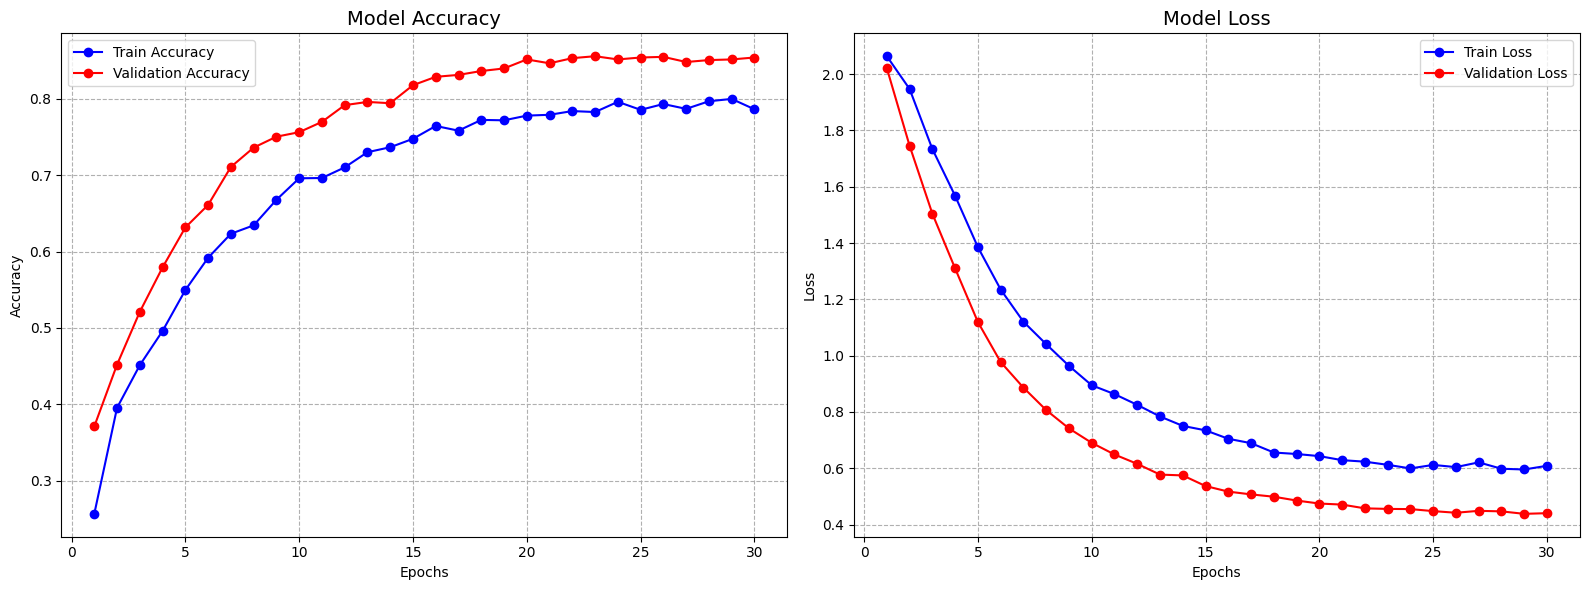

In [39]:
plot_training_history(history)

In [40]:
import torch.nn.functional as F

def ensemble_predict(models, inputs):
    """
    Takes a list of models and returns the averaged predictions.
    """
    outputs = []
    for model in models:
        model.eval()
        with torch.no_grad():
            out = model(inputs)
            probs = F.softmax(out, dim=1)
            outputs.append(probs)
    
    # Average the probabilities
    avg_probs = torch.mean(torch.stack(outputs), dim=0)
    return avg_probs


In [41]:
models_list = [squeezenet_model, shufflenet_model]

inputs, labels = next(iter(val_loader))
inputs = inputs.to(device)

avg_probs = ensemble_predict(models_list, inputs)
_, preds = torch.max(avg_probs, 1)

print("Ensemble Predictions:", preds)

Ensemble Predictions: tensor([4, 5, 4, 7, 0, 5, 6, 7, 4, 4, 3, 3, 7, 1, 5, 0, 4, 3, 5, 7, 3, 1, 2, 7,
        0, 0, 0, 5, 7, 4, 4, 0], device='cuda:0')


In [42]:
import torch.nn.functional as F

def evaluate_ensemble(models, val_loader, device):
    """
    Evaluate ensemble accuracy of multiple trained models on validation set.
    Uses softmax probability averaging.
    """
    for model in models:
        model.eval()
        
    val_corrects, val_total = 0, 0
    val_loss = 0.0
    criterion = nn.CrossEntropyLoss()
    
    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc="Ensemble Validation", leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs_list = []
            for model in models:
                out = model(inputs)
                probs = F.softmax(out, dim=1)
                outputs_list.append(probs)
            
            # Average the softmax outputs
            avg_probs = torch.mean(torch.stack(outputs_list), dim=0)
            
            loss = criterion(avg_probs, labels)
            val_loss += loss.item() * inputs.size(0)
            
            _, preds = torch.max(avg_probs, 1)
            val_corrects += torch.sum(preds == labels.data)
            val_total += labels.size(0)
    
    avg_loss = val_loss / val_total
    avg_acc = val_corrects.double() / val_total
    return avg_loss, avg_acc.item()


In [ ]:
# Train SqueezeNet
squeezenet_model = create_squeezenet_model(num_classes=NUM_CLASSES, pretrained=True)
squeezenet_model, history_sq, ckpt_sq = train_model(
    squeezenet_model, train_loader, val_loader,
    model_name="SqueezeNet_BreakHis", epochs=30, lr=5e-5, patience=7
)

# Train ShuffleNet
shufflenet_model = create_shufflenet_model(num_classes=NUM_CLASSES, pretrained=True)
shufflenet_model, history_sh, ckpt_sh = train_model(
    shufflenet_model, train_loader, val_loader,
    model_name="ShuffleNet_BreakHis", epochs=30, lr=5e-5, patience=7
)

# Evaluate ensemble
ensemble_loss, ensemble_acc = evaluate_ensemble(
    [squeezenet_model, shufflenet_model],
    val_loader, device
)

print(f"\nEnsemble -> Val Loss: {ensemble_loss:.4f}, Val Acc: {ensemble_acc:.4f}")
